In [ ]:
import os
import glob
import pandas as pd

# 1. Read and combine all CSV files
# ---------------------------------------------------
# Update 'data_folder' to the folder where your CSV files are stored.
data_folder = './'
all_files = glob.glob(os.path.join(data_folder, 'reviews_*.csv'))

df_list = []
for file in all_files:
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

# Concatenate all data into one DataFrame
df = pd.concat(df_list, ignore_index=True)

# 2. Drop unwanted columns
# ---------------------------------------------------
df.drop(columns=['product_name', 'review_title', 'review_text'], inplace=True)

# 3. Convert submission_time to datetime
# ---------------------------------------------------
df['submission_time'] = pd.to_datetime(df['submission_time'])

# 4. Aggregate into monthly panel by product
# ---------------------------------------------------
# Group by product_id and monthly submission_time
# Example aggregations below:
#   - rating: mean rating
#   - is_recommended: proportion recommended (mean of 0/1)
#   - helpfulness: mean helpfulness
#   - total_feedback_count: sum of feedback counts
#   - total_neg_feedback_count: sum
#   - total_pos_feedback_count: sum
#   - price_usd: average price over the month
#   - brand_name: first encountered brand name (assuming it's unique per product)
#   - For personal attributes like skin_tone, eye_color, etc., choose a suitable aggregation
#     strategy or possibly drop them if they are not needed at the product-month level.
monthly_panel = (
    df
    .groupby([
        'product_id',
        pd.Grouper(key='submission_time', freq='M')  # Resample by month
    ])
    .agg({
        'rating': 'mean',
        'is_recommended': 'mean',
        'helpfulness': 'mean',
        'total_feedback_count': 'sum',
        'total_neg_feedback_count': 'sum',
        'total_pos_feedback_count': 'sum',
        'price_usd': 'mean',
        'brand_name': 'first',  # or any other strategy
        'skin_tone': 'first',   # or drop / or any other strategy
        'eye_color': 'first',   # or drop / or any other strategy
        'skin_type': 'first',   # or drop / or any other strategy
        'hair_color': 'first'   # or drop / or any other strategy
    })
    .reset_index()
)

# 5. (Optional) Save the monthly panel DataFrame to CSV
# ---------------------------------------------------
monthly_panel.to_csv('product_monthly_panel.csv', index=False)

<ipython-input-2-db13c7e9c288>:13: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file)
<ipython-input-2-db13c7e9c288>:13: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file)
<ipython-input-2-db13c7e9c288>:13: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file)
<ipython-input-2-db13c7e9c288>:45: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key='submission_time', freq='M')  # Resample by month


In [ ]:
import os
import glob
import pandas as pd

# 1. Read and combine all CSV files
# ---------------------------------------------------
# Update 'data_folder' to the folder where your CSV files are stored.
data_folder = './'
all_files = glob.glob(os.path.join(data_folder, 'reviews_*.csv'))

df_list = []
for file in all_files:
    # Set low_memory=False to handle mixed data types
    temp_df = pd.read_csv(file, low_memory=False)
    df_list.append(temp_df)

# Concatenate all data into one DataFrame
df = pd.concat(df_list, ignore_index=True)

# 2. Drop unwanted columns
# ---------------------------------------------------
df.drop(columns=['product_name', 'review_title', 'review_text'], inplace=True)

# 3. Convert submission_time to datetime
# ---------------------------------------------------
df['submission_time'] = pd.to_datetime(df['submission_time'])

# 4. Aggregate into monthly panel by product
# ---------------------------------------------------
# Group by product_id and monthly submission_time
# Use 'ME' for month-end resampling to avoid FutureWarning
monthly_panel = (
    df
    .groupby([
        'product_id',
        pd.Grouper(key='submission_time', freq='ME')  # Resample by month-end
    ])
    .agg({
        'rating': 'mean',
        'is_recommended': 'mean',
        'helpfulness': 'mean',
        'total_feedback_count': 'sum',
        'total_neg_feedback_count': 'sum',
        'total_pos_feedback_count': 'sum',
        'price_usd': 'mean',
        'brand_name': 'first',  # or any other strategy
        'skin_tone': 'first',   # or drop / or any other strategy
        'eye_color': 'first',   # or drop / or any other strategy
        'skin_type': 'first',   # or drop / or any other strategy
        'hair_color': 'first'   # or drop / or any other strategy
    })
    .reset_index()
)

# 5. (Optional) Save the monthly panel DataFrame to CSV
# ---------------------------------------------------
monthly_panel.to_csv('product_monthly_panel.csv', index=False)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#regression modeling and diagnostics
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan

# For normality test
from scipy.stats import shapiro

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set seaborn style
sns.set(style="whitegrid")

# 1. Load Data
df = pd.read_csv("product_monthly_panel.csv")

# 2. Data Preprocessing
# Convert submission_time to datetime
df['submission_time'] = pd.to_datetime(df['submission_time'])

# Handle missing values
df['is_recommended'].fillna(df['is_recommended'].mean(), inplace=True)
df['helpfulness'].fillna(df['helpfulness'].mean(), inplace=True)

# Drop rows with missing target (rating)
df.dropna(subset=['rating'], inplace=True)

# Encode categorical variables
df_encoded = pd.get_dummies(df, columns=['brand_name', 'skin_tone', 'eye_color', 'skin_type', 'hair_color'], drop_first=True)


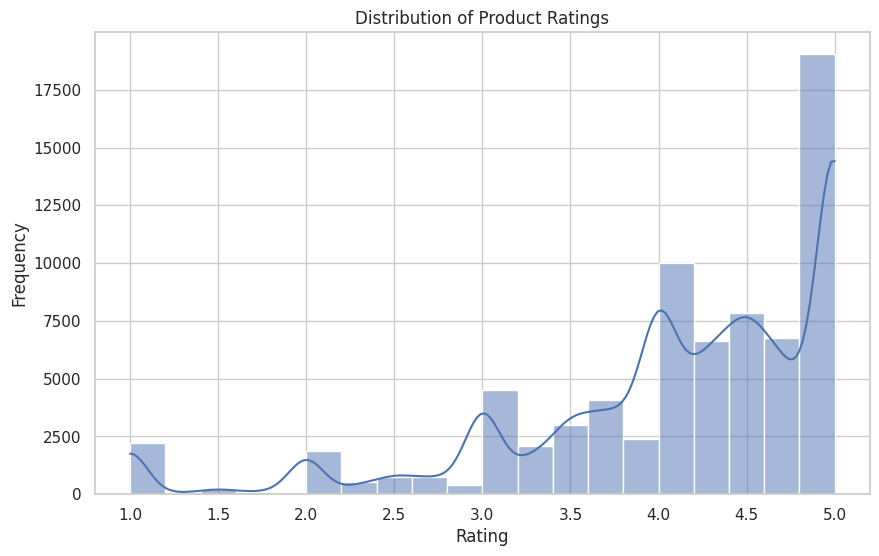

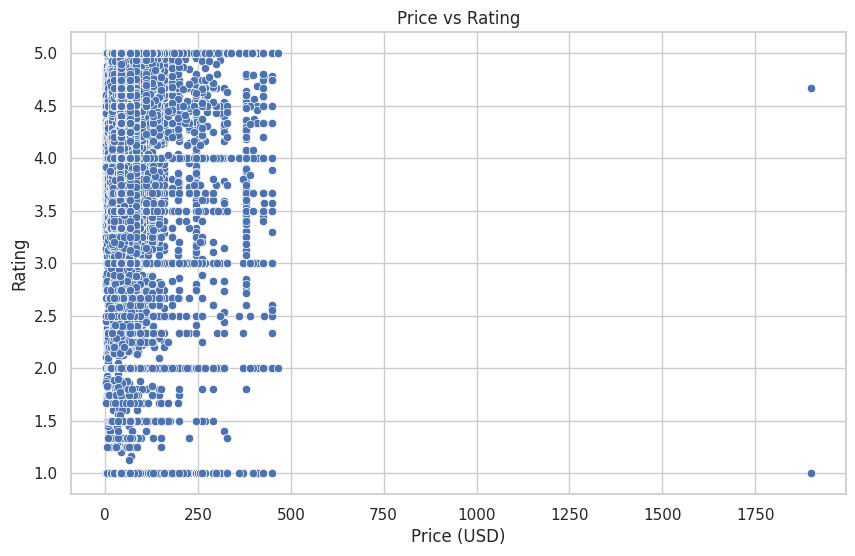

In [ ]:
# 3. Exploratory Data Analysis
plt.figure(figsize=(10,6))
sns.histplot(df['rating'], bins=20, kde=True)
plt.title('Distribution of Product Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(x='price_usd', y='rating', data=df)
plt.title('Price vs Rating')
plt.xlabel('Price (USD)')
plt.ylabel('Rating')
plt.show()


In [ ]:
# Check data types
print(X.dtypes)
print(y.dtypes)


is_recommended              float64
helpfulness                 float64
total_feedback_count          int64
total_neg_feedback_count      int64
total_pos_feedback_count      int64
                             ...   
hair_color_blonde              bool
hair_color_brown               bool
hair_color_brunette            bool
hair_color_gray                bool
hair_color_red                 bool
Length: 173, dtype: object
float64


In [ ]:
# Convert boolean columns to integers (0/1)
X = X.astype({col: 'int' for col in X.select_dtypes(include=['bool']).columns})

In [ ]:
# 4. Multiple Linear Regression
# Define features and target
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

# Convert boolean columns to integers
X = X.astype({col: 'int' for col in X.select_dtypes(include=['bool']).columns})

# Drop any rows with NaN values
combined = pd.concat([X, y], axis=1).dropna()
X = combined.drop(y.name, axis=1)
y = combined[y.name]

# Add constant term
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.711
Model:                            OLS   Adj. R-squared:                  0.710
Method:                 Least Squares   F-statistic:                     1045.
Date:                Sat, 22 Feb 2025   Prob (F-statistic):               0.00
Time:                        23:20:08   Log-Likelihood:                -54470.
No. Observations:               73272   AIC:                         1.093e+05
Df Residuals:                   73099   BIC:                         1.109e+05
Df Model:                         172                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

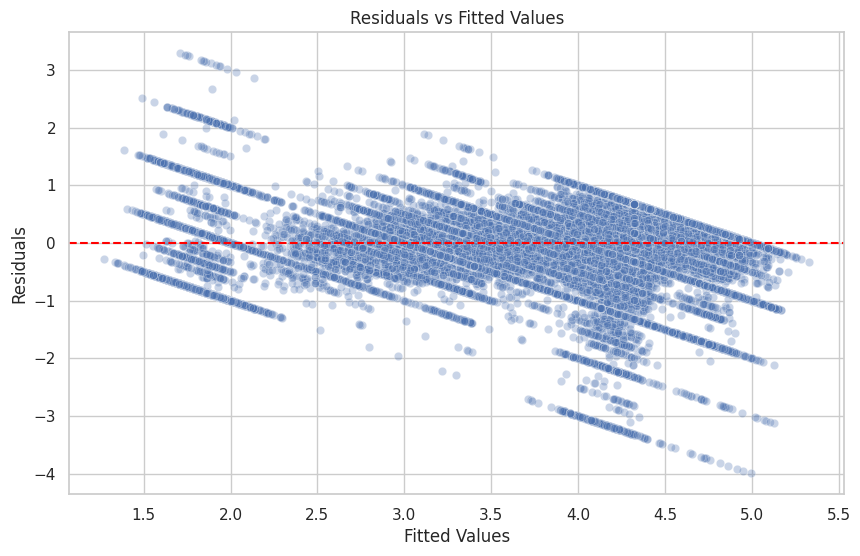

In [ ]:
# 5. Regression Diagnostics
# 5.1. Residuals vs Fitted
fitted_vals = model.predict(X)
residuals = y - fitted_vals

plt.figure(figsize=(10,6))
sns.scatterplot(x=fitted_vals, y=residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

In [ ]:
# 5.2. Durbin-Watson Test
dw = durbin_watson(residuals)
print(f'Durbin-Watson statistic: {dw}')

Durbin-Watson statistic: 1.8064964152744707


In [ ]:
#5.3. Breusch-Pagan Test
bp_test = het_breuschpagan(residuals, model.model.exog)
labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
print('\nBreusch-Pagan test results:')
for name, val in zip(labels, bp_test):
    print(f'{name}: {val}')


Breusch-Pagan test results:
Lagrange multiplier statistic: 5651.186243599436
p-value: 0.0
f-value: 35.51748588012894
f p-value: 0.0


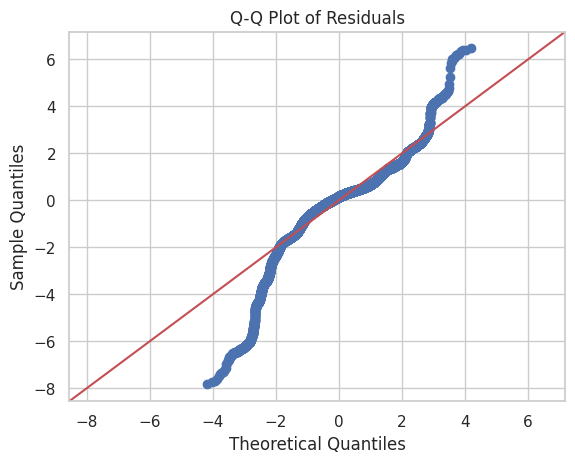

In [ ]:
# 5.4. Normality of Errors
sm.qqplot(residuals, line='45', fit=True)
plt.title('Q-Q Plot of Residuals')
plt.show()

In [ ]:
# Shapiro-Wilk Test
sample_residuals = residuals.sample(5000, random_state=1)
shapiro_test = shapiro(sample_residuals)
print(f'Shapiro-Wilk test statistic: {shapiro_test.statistic}, p-value: {shapiro_test.pvalue}')


Shapiro-Wilk test statistic: 0.9031154945542494, p-value: 1.1151793921223057e-48



Variance Inflation Factor (VIF):
                        Feature        VIF
0                         const  64.860543
160             eye_color_brown   9.023141
169            hair_color_brown   6.122992
159              eye_color_blue   5.429379
15          brand_name_CLINIQUE   4.762178
..                          ...        ...
88        brand_name_Nécessaire        NaN
93   brand_name_PROVEN Skincare        NaN
114  brand_name_Soleil Toujours        NaN
139          brand_name_caliray        NaN
154         skin_tone_notSureST        NaN

[173 rows x 2 columns]


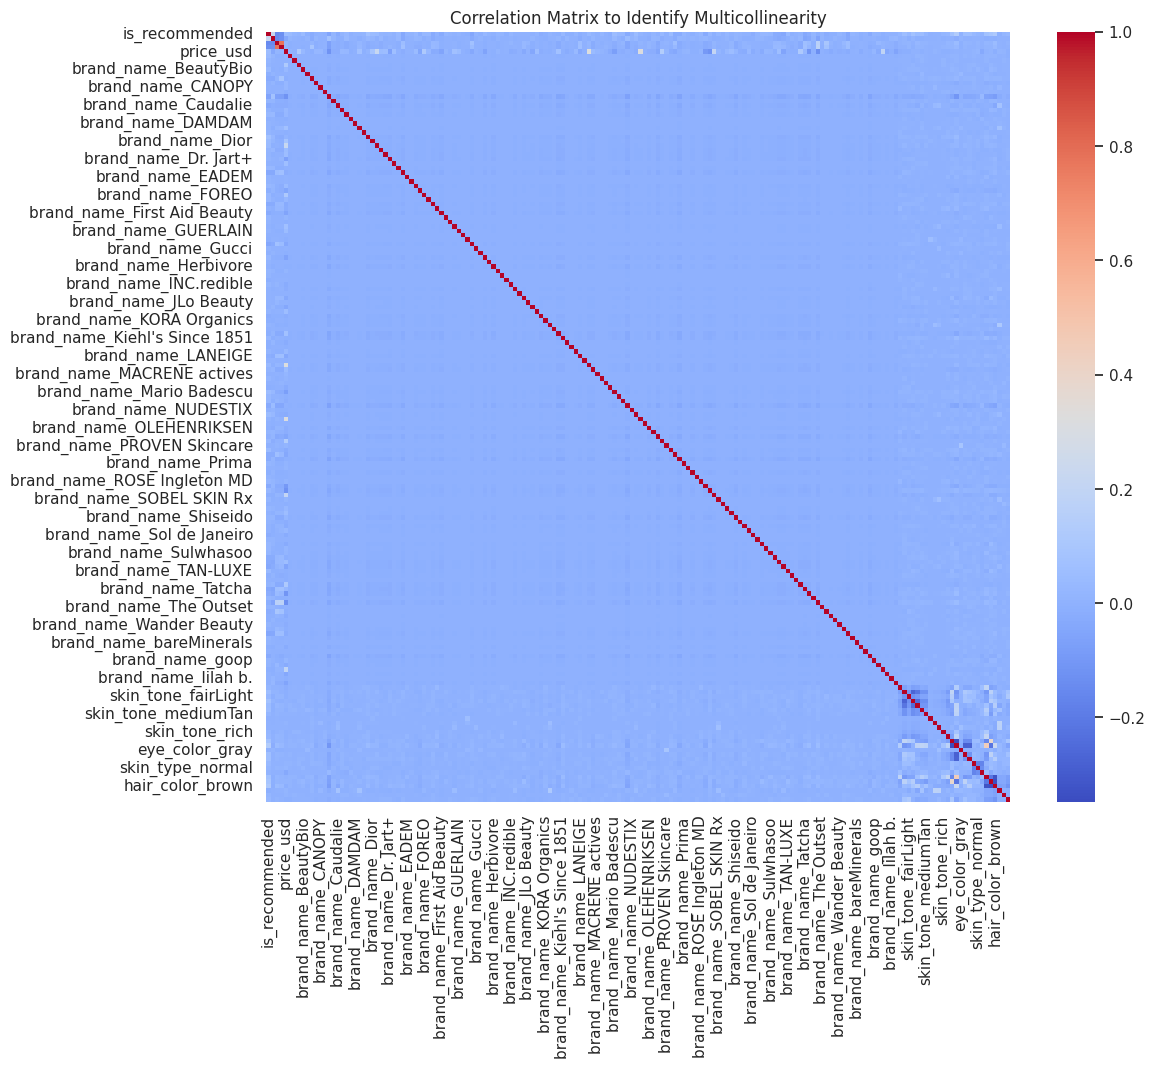

In [30]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Load your dataset (replace with your actual file path or upload in Colab)
# df = pd.read_csv('/path_to_your_dataset.csv')
# Assuming df_encoded is your preprocessed DataFrame

# Define features (X) and target (y)
X = df_encoded.drop(['product_id', 'submission_time', 'rating'], axis=1, errors='ignore')

# Convert boolean columns to integers (0/1)
X = X.astype(int)

# Drop perfectly collinear features (e.g., total_feedback_count)
X = X.drop(['total_feedback_count'], axis=1, errors='ignore')

# Sample the dataset to reduce memory usage for VIF calculation
X_sampled = X.sample(n=5000, random_state=42)

# Add constant term for intercept
X_sampled = sm.add_constant(X_sampled)

# Calculate VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = X_sampled.columns
vif_data['VIF'] = [variance_inflation_factor(X_sampled.values, i) for i in range(X_sampled.shape[1])]

# Display VIF
print('\nVariance Inflation Factor (VIF):')
print(vif_data.sort_values(by='VIF', ascending=False))

# Plot Correlation Matrix as Alternative

# Calculate correlation matrix
corr_matrix = X.corr()

# Plot heatmap of correlations
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title("Correlation Matrix to Identify Multicollinearity")
plt.show()
